# Embedding Model Evaluation — Triage Explorer Research

Comparative analysis of embedding models across tasks and modalities.
Results are loaded from `results/log.json`, which is updated each time an evaluation script runs.

**Tasks:**
- `SortingTask` → ARI (Adjusted Rand Index): how well embeddings cluster into correct categories. Range [-1, 1], higher is better.
- `RetrievalTask` → Precision@K and MRR: how well embeddings rank relevant documents. Range [0, 1], higher is better.

---

In [29]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

with open('results/log.json') as f:
    raw = json.load(f)

# Flatten into a DataFrame
rows = []
for entry in raw:
    row = {
        'date': pd.to_datetime(entry['date']),
        'engine': entry['engine'],
        'modality': entry['modality'],
        'dataset': entry['dataset'],
        **entry['metrics'],
    }
    rows.append(row)

all_df = pd.DataFrame(rows)

# Split by modality — existing sections operate on text only
text_df = all_df[all_df['modality'] == 'text'].copy()
image_df = all_df[all_df['modality'] == 'image'].copy()

df = text_df  # used by all sections below
print(f"Total runs: {len(all_df)}  (text: {len(text_df)} | image: {len(image_df)})")
df

Total runs: 11  (text: 9 | image: 2)


,date,engine,modality,dataset,sorting_ari,retrieval_precision_at_5,retrieval_map,retrieval_mrr
0,2026-04-14,TF-IDF,text,20newsgroups,0.362418,0.804,0.406556,0.851286
1,2026-04-14,Word2Vec,text,20newsgroups,0.036165,0.422,0.296312,0.603774
2,2026-04-14,FastText,text,20newsgroups,0.013862,0.310,0.267649,0.513023
3,2026-04-14,Word2Vec-Pretrained,text,20newsgroups,0.269213,0.794,0.416020,0.891762
4,2026-04-14,FastText-Pretrained,text,20newsgroups,0.026685,0.646,0.318089,0.831842
5,2026-04-14,SBERT-Small,text,20newsgroups,0.717450,0.882,0.650989,0.955788
6,2026-04-14,SBERT-Large,text,20newsgroups,0.742432,0.902,0.685908,0.966477
7,2026-04-14,SBERT-XLarge,text,20newsgroups,0.575312,0.880,0.603644,0.950640
8,2026-04-14,ColBERT,text,20newsgroups,0.387720,0.824,0.508850,0.929103


## Model Comparison — All Metrics

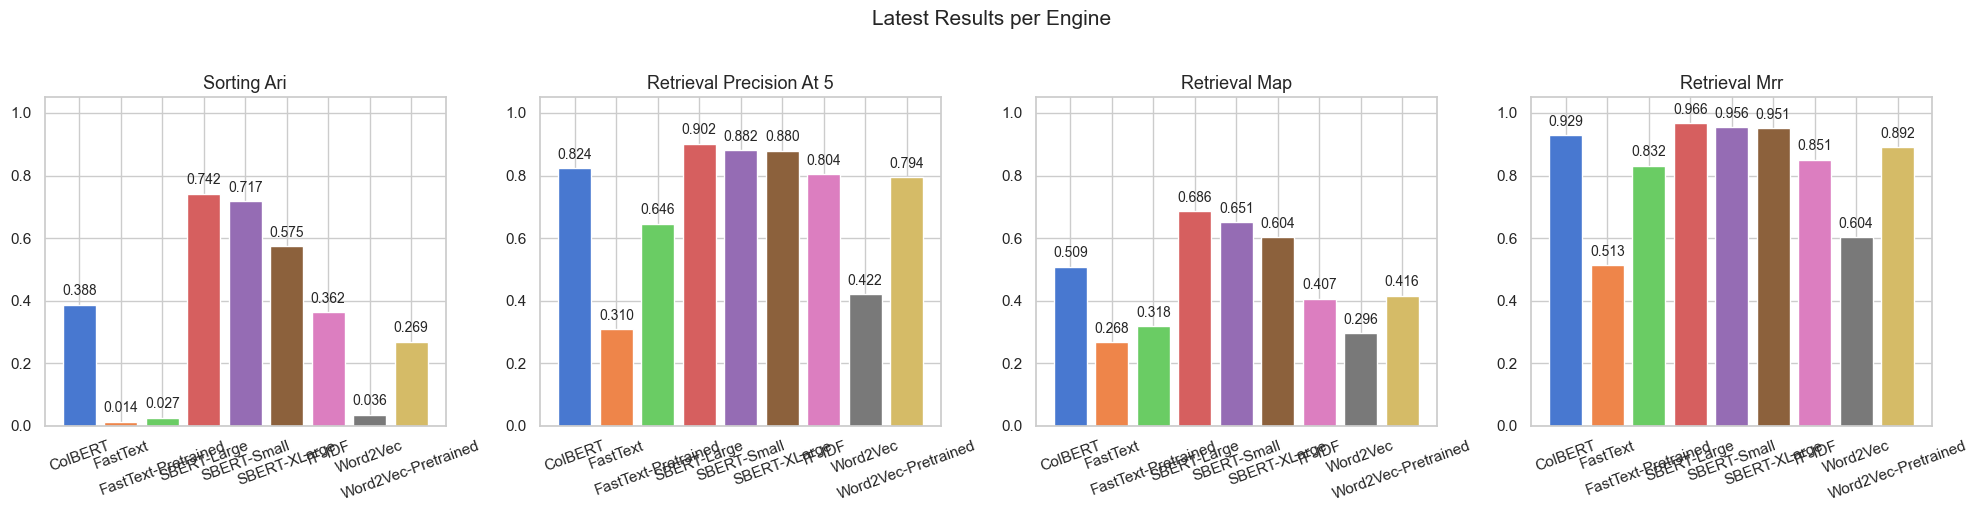

In [30]:
# Identify metric columns (everything after the fixed columns)
fixed_cols = {'date', 'engine', 'modality', 'dataset'}
metric_cols = [c for c in df.columns if c not in fixed_cols]

# Latest run per engine
latest = df.sort_values('date').groupby('engine').last().reset_index()

fig, axes = plt.subplots(1, len(metric_cols), figsize=(5 * len(metric_cols), 5))
if len(metric_cols) == 1:
    axes = [axes]

for ax, metric in zip(axes, metric_cols):
    bars = ax.bar(latest['engine'], latest[metric], color=sns.color_palette('muted', len(latest)))
    ax.set_title(metric.replace('_', ' ').title(), fontsize=13)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, latest[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)

fig.suptitle('Latest Results per Engine', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## Progress Over Time — per Metric

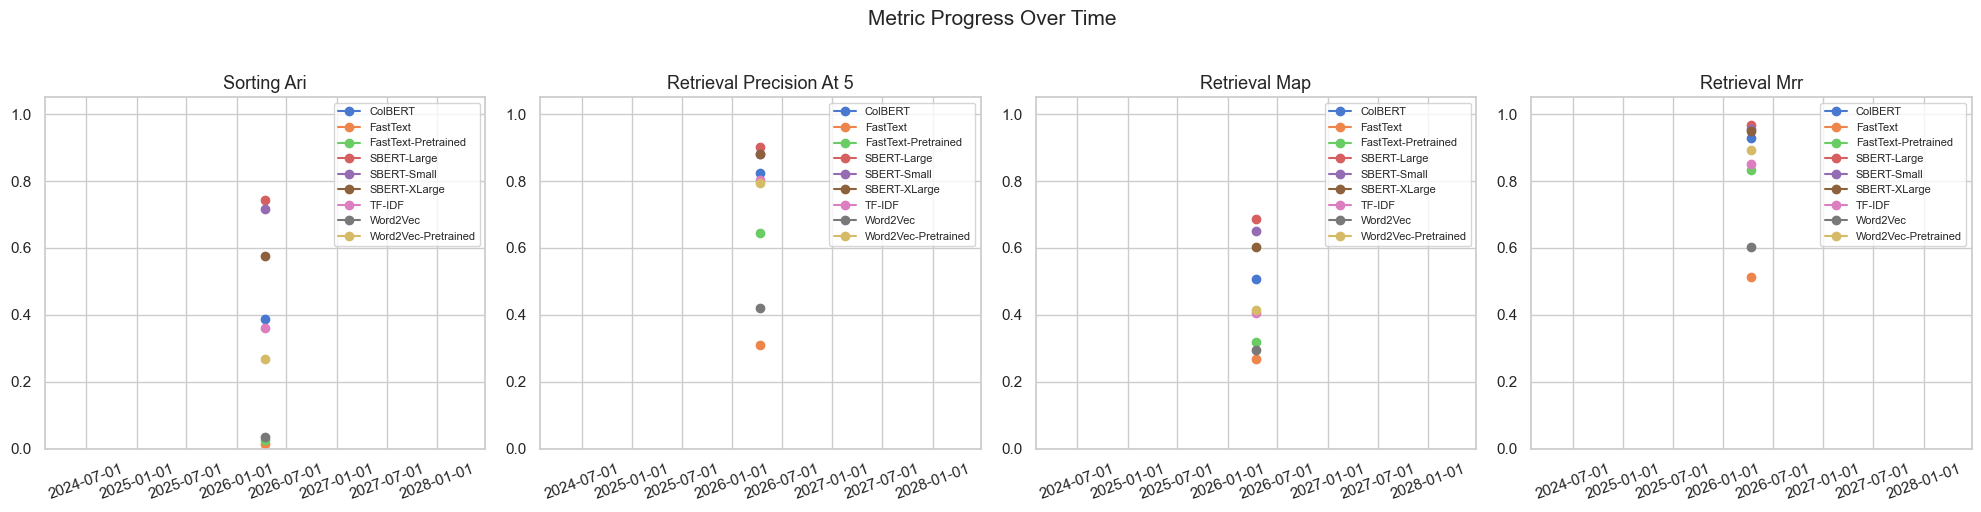

In [31]:
fig, axes = plt.subplots(1, len(metric_cols), figsize=(5 * len(metric_cols), 5))
if len(metric_cols) == 1:
    axes = [axes]

for ax, metric in zip(axes, metric_cols):
    for engine, group in df.groupby('engine'):
        group = group.sort_values('date')
        ax.plot(group['date'], group[metric], marker='o', label=engine)
    ax.set_title(metric.replace('_', ' ').title(), fontsize=13)
    ax.set_ylim(0, 1.05)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.tick_params(axis='x', rotation=20)
    ax.legend(fontsize=8)

fig.suptitle('Metric Progress Over Time', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## Sorting vs Retrieval Trade-off

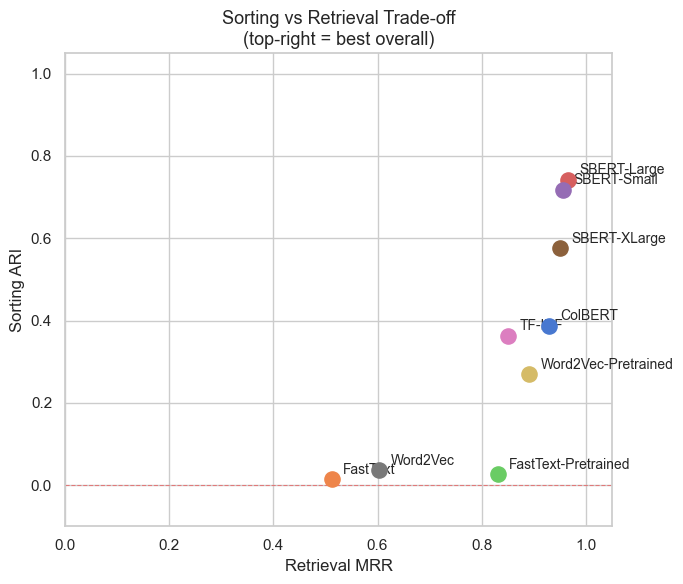

In [32]:
if 'sorting_ari' in df.columns and 'retrieval_mrr' in df.columns:
    fig, ax = plt.subplots(figsize=(7, 6))
    for _, row in latest.iterrows():
        ax.scatter(row['retrieval_mrr'], row['sorting_ari'], s=120, zorder=5)
        ax.annotate(row['engine'], (row['retrieval_mrr'], row['sorting_ari']),
                    textcoords='offset points', xytext=(8, 4), fontsize=10)
    ax.set_xlabel('Retrieval MRR', fontsize=12)
    ax.set_ylabel('Sorting ARI', fontsize=12)
    ax.set_xlim(0, 1.05)
    ax.set_ylim(-0.1, 1.05)
    ax.set_title('Sorting vs Retrieval Trade-off\n(top-right = best overall)', fontsize=13)
    ax.axhline(0, color='red', linewidth=0.8, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()
else:
    print("Add more models to see the trade-off chart.")

## Raw Results Table

In [33]:
display(df.sort_values(['engine', 'date']).reset_index(drop=True).style.format(
    {col: '{:.4f}' for col in metric_cols}
).background_gradient(subset=metric_cols, cmap='YlGn'))

,date,engine,modality,dataset,sorting_ari,retrieval_precision_at_5,retrieval_map,retrieval_mrr
0,2026-04-14 00:00:00,ColBERT,text,20newsgroups,0.3877,0.8240,0.5089,0.9291
1,2026-04-14 00:00:00,FastText,text,20newsgroups,0.0139,0.3100,0.2676,0.5130
2,2026-04-14 00:00:00,FastText-Pretrained,text,20newsgroups,0.0267,0.6460,0.3181,0.8318
3,2026-04-14 00:00:00,SBERT-Large,text,20newsgroups,0.7424,0.9020,0.6859,0.9665
4,2026-04-14 00:00:00,SBERT-Small,text,20newsgroups,0.7175,0.8820,0.6510,0.9558
5,2026-04-14 00:00:00,SBERT-XLarge,text,20newsgroups,0.5753,0.8800,0.6036,0.9506
6,2026-04-14 00:00:00,TF-IDF,text,20newsgroups,0.3624,0.8040,0.4066,0.8513
7,2026-04-14 00:00:00,Word2Vec,text,20newsgroups,0.0362,0.4220,0.2963,0.6038
8,2026-04-14 00:00:00,Word2Vec-Pretrained,text,20newsgroups,0.2692,0.7940,0.4160,0.8918


## Improvement Analysis: Scratch vs Pretrained

In [34]:
## Compare Scratch vs Pretrained models
comparison_df = df.copy()
if not comparison_df.empty:
    # Standardize types for comparison
    comparison_df['type'] = comparison_df['engine'].apply(lambda x: 'Pretrained' if 'Pretrained' in x else 'Scratch')
    comparison_df['base_engine'] = comparison_df['engine'].str.replace('-Scratch|-Pretrained', '', regex=True)
    
    # Only keep engines that have both versions
    counts = comparison_df.groupby('base_engine')['type'].nunique()
    valid_engines = counts[counts == 2].index
    comparison_df = comparison_df[comparison_df['base_engine'].isin(valid_engines)]

    if not comparison_df.empty:
        pivot = comparison_df.pivot_table(
            index='base_engine', 
            columns='type', 
            values=['sorting_ari', 'retrieval_precision_at_5']
        )

        # Calculate improvement %
        for metric in ['sorting_ari', 'retrieval_precision_at_5']:
            pivot[(metric, 'Gain %')] = (
                (pivot[(metric, 'Pretrained')] - pivot[(metric, 'Scratch')]) / 
                pivot[(metric, 'Scratch')] * 100
            )

        print("Semantic Gain from Pre-training (Wikipedia/News knowledge):")
        display(pivot.style.format('{:.2f}%', subset=[(m, 'Gain %') for m in ['sorting_ari', 'retrieval_precision_at_5']]))
    else:
        print("No matching Scratch/Pretrained pairs found for comparison.")
else:
    print("No data found in log.json.")

Semantic Gain from Pre-training (Wikipedia/News knowledge):


## SBERT Size Comparison: Small vs Large vs XLarge

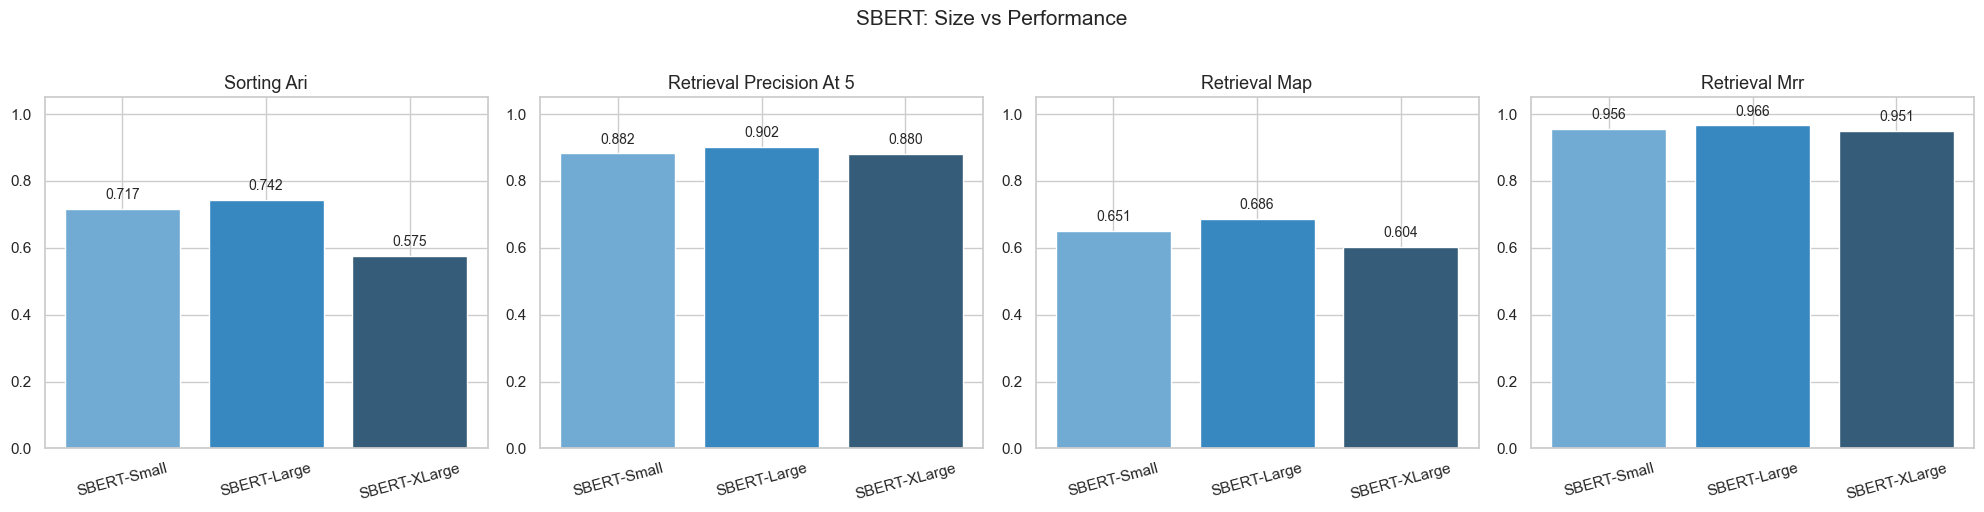


Gain over SBERT-Small (%):


engine,sorting_ari,retrieval_precision_at_5,retrieval_map,retrieval_mrr
SBERT-Small,+0.0%,+0.0%,+0.0%,+0.0%
SBERT-Large,+3.5%,+2.3%,+5.4%,+1.1%
SBERT-XLarge,-19.8%,-0.2%,-7.3%,-0.5%


In [35]:
sbert_order = ["SBERT-Small", "SBERT-Large", "SBERT-XLarge"]
sbert_df = latest[latest['engine'].isin(sbert_order)].copy()
sbert_df['engine'] = pd.Categorical(sbert_df['engine'], categories=sbert_order, ordered=True)
sbert_df = sbert_df.sort_values('engine')

if sbert_df.empty:
    print("No SBERT results yet — run the benchmark first.")
else:
    fig, axes = plt.subplots(1, len(metric_cols), figsize=(5 * len(metric_cols), 5))
    if len(metric_cols) == 1:
        axes = [axes]

    palette = sns.color_palette("Blues_d", len(sbert_df))

    for ax, metric in zip(axes, metric_cols):
        bars = ax.bar(sbert_df['engine'], sbert_df[metric], color=palette)
        ax.set_title(metric.replace('_', ' ').title(), fontsize=13)
        ax.set_ylim(0, 1.05)
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=15)
        for bar, val in zip(bars, sbert_df[metric]):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=10)

    fig.suptitle('SBERT: Size vs Performance', fontsize=15, y=1.02)
    plt.tight_layout()
    plt.show()

    # Gain table relative to Small
    if len(sbert_df) > 1:
        print("\nGain over SBERT-Small (%):")
        base = sbert_df[sbert_df['engine'] == 'SBERT-Small'][metric_cols].values[0]
        gain_df = sbert_df[['engine']].copy().reset_index(drop=True)
        for i, metric in enumerate(metric_cols):
            gain_df[metric] = ((sbert_df[metric].values - base[i]) / base[i] * 100)
        display(gain_df.style.format({m: '{:+.1f}%' for m in metric_cols}).hide(axis='index'))

---
## Image Results — STL-10

Image-to-image evaluation on STL-10 (10 classes, 96×96 RGB).
- **ColorHistogram** → baseline, RGB histogram features, no ML
- **CLIP-ViT-B32** → contrastive vision-language model

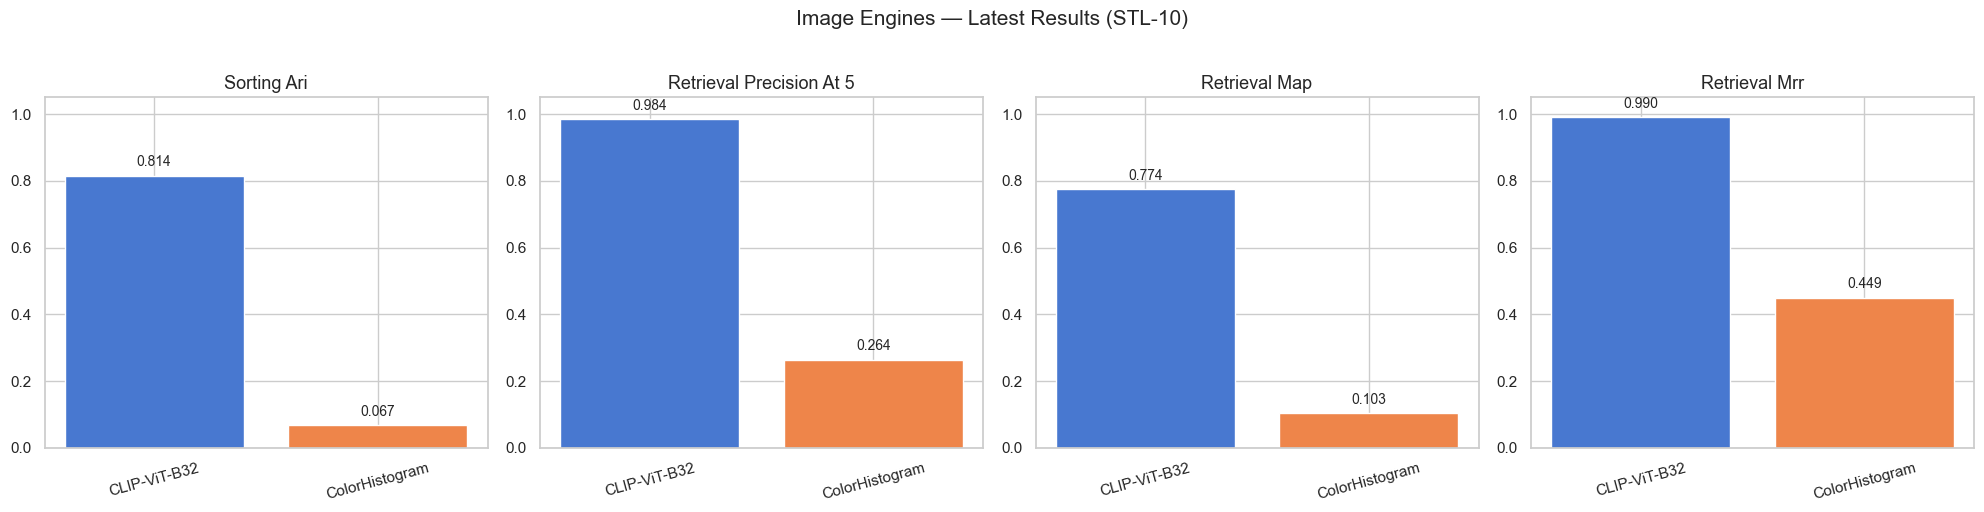


Gain over ColorHistogram baseline (%):


engine,sorting_ari,retrieval_precision_at_5,retrieval_map,retrieval_mrr
CLIP-ViT-B32,+1109.5%,+272.7%,+651.6%,+120.6%
ColorHistogram,+0.0%,+0.0%,+0.0%,+0.0%


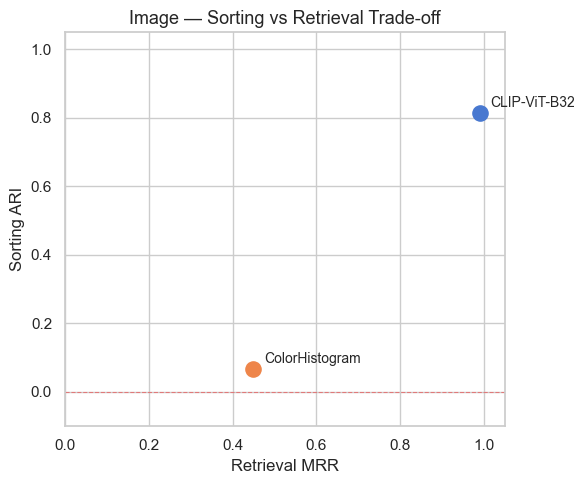

In [36]:
if image_df.empty:
    print("No image results yet — run src/evaluation/run_image_baseline.py first.")
else:
    img_fixed_cols = {'date', 'engine', 'modality', 'dataset'}
    img_metric_cols = [c for c in image_df.columns if c not in img_fixed_cols]
    img_latest = image_df.sort_values('date').groupby('engine').last().reset_index()

    # Bar chart per metric
    fig, axes = plt.subplots(1, len(img_metric_cols), figsize=(5 * len(img_metric_cols), 5))
    if len(img_metric_cols) == 1:
        axes = [axes]

    palette = sns.color_palette('muted', len(img_latest))
    for ax, metric in zip(axes, img_metric_cols):
        bars = ax.bar(img_latest['engine'], img_latest[metric], color=palette)
        ax.set_title(metric.replace('_', ' ').title(), fontsize=13)
        ax.set_ylim(0, 1.05)
        ax.tick_params(axis='x', rotation=15)
        for bar, val in zip(bars, img_latest[metric]):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=10)

    fig.suptitle('Image Engines — Latest Results (STL-10)', fontsize=15, y=1.02)
    plt.tight_layout()
    plt.show()

    # Gain table: CLIP vs ColorHistogram baseline
    if 'ColorHistogram' in img_latest['engine'].values and len(img_latest) > 1:
        print("\nGain over ColorHistogram baseline (%):")
        base = img_latest[img_latest['engine'] == 'ColorHistogram'][img_metric_cols].values[0]
        gain_df = img_latest[['engine']].copy().reset_index(drop=True)
        for i, metric in enumerate(img_metric_cols):
            gain_df[metric] = (img_latest[metric].values - base[i]) / abs(base[i]) * 100
        display(gain_df.style.format({m: '{:+.1f}%' for m in img_metric_cols}).hide(axis='index'))

    # Sorting vs Retrieval scatter
    if 'sorting_ari' in img_metric_cols and 'retrieval_mrr' in img_metric_cols:
        fig, ax = plt.subplots(figsize=(6, 5))
        for _, row in img_latest.iterrows():
            ax.scatter(row['retrieval_mrr'], row['sorting_ari'], s=120, zorder=5)
            ax.annotate(row['engine'], (row['retrieval_mrr'], row['sorting_ari']),
                        textcoords='offset points', xytext=(8, 4), fontsize=10)
        ax.set_xlabel('Retrieval MRR', fontsize=12)
        ax.set_ylabel('Sorting ARI', fontsize=12)
        ax.set_xlim(0, 1.05)
        ax.set_ylim(-0.1, 1.05)
        ax.set_title('Image — Sorting vs Retrieval Trade-off', fontsize=13)
        ax.axhline(0, color='red', linewidth=0.8, linestyle='--', alpha=0.4)
        plt.tight_layout()
        plt.show()